TASK 1 — MCP NEURON

In [3]:
# MCP Neuron for AND Gate
def MCP_AND(X1, X2, T=2):
    result = []
    for i in range(len(X1)):
        s = X1[i] + X2[i]
        if s >= T:
            result.append(1)
        else:
            result.append(0)
    return result


# MCP Neuron for OR Gate
def MCP_OR(X1, X2, T=1):
    result = []
    for i in range(len(X1)):
        s = X1[i] + X2[i]
        if s >= T:
            result.append(1)
        else:
            result.append(0)
    return result


# MCP Neuron for NAND Gate
def MCP_NAND(X1, X2, T=2):
    result = []
    for i in range(len(X1)):
        s = X1[i] + X2[i]
        if s >= T:
            result.append(0)   # opposite of AND
        else:
            result.append(1)
    return result


# Inputs
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]

# Run all gates
and_result = MCP_AND(X1, X2)
or_result = MCP_OR(X1, X2)
nand_result = MCP_NAND(X1, X2)

# Print results
print("AND Gate Output :", and_result)
print("OR Gate Output  :", or_result)
print("NAND Gate Output:", nand_result)

AND Gate Output : [0, 0, 0, 1]
OR Gate Output  : [0, 1, 1, 1]
NAND Gate Output: [1, 1, 1, 0]


Task2: PERCEPTRON

In [5]:
##load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_0_1 = pd.read_csv("/content/mnist_0_and_1.csv")

X = df_0_1.drop(columns=["label"]).values
y = df_0_1["label"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12665, 784)
y shape: (12665,)


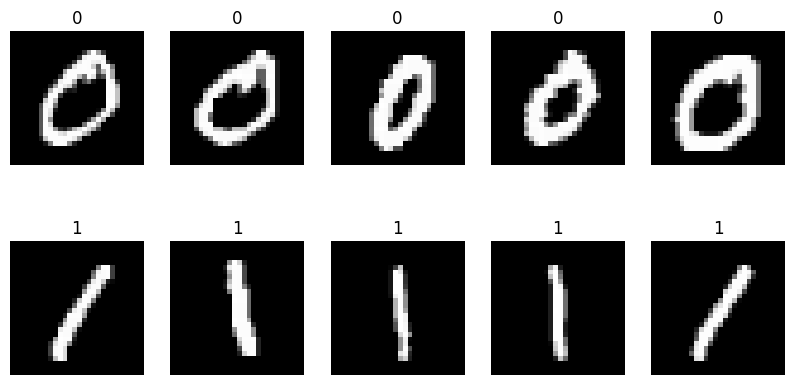

In [6]:
##Visualize Data
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("0")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("1")
    axes[1, i].axis("off")

plt.show()

In [7]:
#Initialize Weights
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

In [8]:
#Decision Function
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    return np.where(predictions >= 0, 1, 0)

In [9]:
#Train Perceptron
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0

            if y_pred != y[i]:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)
            else:
                correct += 1

    accuracy = correct / len(X)
    return weights, bias, accuracy

In [10]:
#Train Model
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy:", accuracy)

Final Accuracy: 1.0


In [11]:
#Predictions + Accuracy
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

final_accuracy = np.mean(y_pred == y)
print("Accuracy:", final_accuracy)

Accuracy: 1.0


In [12]:
#Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"P:{y_pred[idx]} T:{y[idx]}")
        ax.axis("off")

    plt.show()
else:
    print("All images were correctly classified!")

All images were correctly classified!


TASK 3 — PERCEPTRON (3 vs 5)

In [14]:
df_3_5 = pd.read_csv("/content/mnist_3_and_5.csv")

X = df_3_5.drop(columns=["label"]).values
y = df_3_5["label"].values

In [15]:
y = np.where(y == 3, 0, 1)

In [16]:
weights = np.zeros(X.shape[1])
bias = 0

weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Accuracy:", accuracy)

Accuracy: 0.9857716161984678


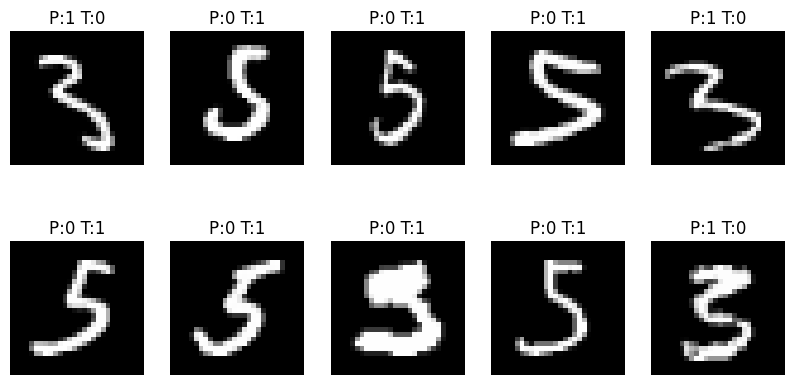

In [17]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"P:{y_pred[idx]} T:{y[idx]}")
        ax.axis("off")

    plt.show()
else:
    print("All correct!")

In [13]:
#The perceptron works well for simple classification like 0 vs 1.
#However, for 3 vs 5, accuracy is lower because the digits are more similar.
#This shows the limitation of perceptron in complex classification problems.